# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160124          # <-- your full roll number
NAME = "Mukul"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160124   Name: Mukul   Fingerprint: CDD9C164   Tickets: 16

Ticket_ID                                                                               Ticket_Text
      T01         I tried restarting the laptop before the assignment deadline. Can you check this?
      T02             Student portal crashes while opening after the latest update. This is urgent.
      T03 Laptop is showing an error before the assignment deadline. The same problem occurs again.
      T04                   Password was working yesterday on my laptop. I don't know what changed.
      T05                             I am unable to use the password on my laptop. This is urgent.
      T06                        I keep getting logged out of the VPN on my laptop. This is urgent.
      T07                                 The student portal stopped responding. Please resolve it.
      T08           MATLAB has stopped syncing while uploading the file. I don't know what changed.
      T09              

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
# Your code
import pandas as pd

# Process all tickets
records = []
for idx, row in df.iterrows():
    res = process_ticket(row["Ticket_Text"])
    records.append(
        {
            "Ticket_ID": row["Ticket_ID"],
            "Sentences": len(res["sentences"]),
            "Tokens": len(res["tokens"]),
            "Punctuation": len(res["punct"]),
            "Stopwords": len(res["stops"]),
            "Unique Tokens": len(set(res["tokens"])),
            "Final Tokens": len(res["final"]),
        }
    )

table_df = pd.DataFrame(records)

# Compute TOTAL row
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": table_df["Sentences"].sum(),
    "Tokens": table_df["Tokens"].sum(),
    "Punctuation": table_df["Punctuation"].sum(),
    "Stopwords": table_df["Stopwords"].sum(),
    "Unique Tokens": len(
        set(
            t
            for text in df["Ticket_Text"]
            for t in process_ticket(text)["tokens"]
        )
    ),
    "Final Tokens": table_df["Final Tokens"].sum(),
}

table_df = pd.concat(
    [table_df, pd.DataFrame([total_row])], ignore_index=True
)
print(table_df.to_string(index=False))

# Display breakdown for selected ticket T01
t1_res = process_ticket(df.loc[df["Ticket_ID"] == "T01", "Ticket_Text"].values[0])
print("\n--- Selected Ticket (T01) Detail ---")
print("Tokens:", t1_res["tokens"])
print("Punctuation:", t1_res["punct"])
print("Stopwords:", t1_res["stops"])
print("Final Tokens:", t1_res["final"])

Ticket_ID  Sentences  Tokens  Punctuation  Stopwords  Unique Tokens  Final Tokens
      T01          2      15            2          7             14             6
      T02          2      14            2          5             13             7
      T03          2      16            2          7             14             7
      T04          2      15            2          6             14             7
      T05          2      15            2          8             14             5
      T06          2      16            2          8             15             6
      T07          2      10            2          2              9             6
      T08          2      16            2          6             15             8
      T09          1       7            1          3              7             3
      T10          2      18            2          6             17            10
      T11          2      10            4          2              9             4
      T12       

**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

These tokens come from NLTK's word_tokenize() (which uses the Penn Treebank tokenization rules). NLTK splits English contractions like "can't" into "ca" and "n't", and "don't" into "do" and "n't", treating the apostrophe negations as separate grammatical units. Since n't and ca are not in the standard NLTK stopwords list and contain alphanumeric characters, they pass through to final tokens.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
import re
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

# Regex patterns
words_gt_5 = r"\b[A-Za-z]{6,}\b"
numbers_pat = r"\b\d+(?:[\.,]\d+)*\b"
capitalized_pat = r"\b[A-Z][a-z]*\b"
vowels_pat = r"\b[aeiouAEIOU][a-zA-Z]*\b"

email_pat = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
url_pat = r"https?://\S+|www\.\S+"
phone_pat = r"(?:\+\d{1,3}[\s-]?)?\(?\d{3,5}\)?[\s-]?\d{3,5}[\s-]?\d{3,5}\b"

print("--- Extraction on TEST_LINES ---")
for line in TEST_LINES:
    print("Line:", line)
    print("  > 5 letters:", re.findall(words_gt_5, line))
    print("  Numbers:", re.findall(numbers_pat, line))
    print("  Capitalized:", re.findall(capitalized_pat, line))
    print("  Vowel start:", re.findall(vowels_pat, line))

print("\n--- Substitution on TEST_LINES ---")
for line in TEST_LINES:
    clean = re.sub(email_pat, "", line)
    clean = re.sub(url_pat, "", clean)
    clean = re.sub(phone_pat, "", clean)
    print(clean)
# Your code

--- Extraction on TEST_LINES ---
Line: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
  > 5 letters: ['helpdesk', 'thapar', 'thapar', 'thapar']
  Numbers: []
  Capitalized: ['Mail']
  Vowel start: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']
Line: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
  > 5 letters: ['Version']
  Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']
  Capitalized: ['Call', 'Version', 'Rs']
  Vowel start: ['or', 'is']
Line: The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
  > 5 letters: []
  Numbers: ['5.30']
  Capitalized: ['The']
  Vowel start: ['of', 'art', 'isn', 'open', 'in', 'at']

--- Substitution on TEST_LINES ---
Mail  or ; visit  or 
Call +91 98765 43210, +91-98765-43210 or . Version 2.0.1 is 95.5% done; fee Rs 1,250.
The state-of-the-art l

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

In our dataset, 19 words are capitalized purely due to sentence-initial position (e.g., "Student" in T02, "Laptop" in T03, "Password" in T04, "The" across multiple tickets). Proper nouns and acronyms like "MATLAB", "Wi-Fi", and "Windows" are inherently capitalized regardless of position.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
# Your code
from nltk.tokenize import RegexpTokenizer

# Regex Pattern preserving contractions, hyphens, decimals/versions, emails, URLs, and phone numbers
custom_pattern = r"""(?x)
    \b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b   # Emails
  | https?://\S+|www\.\S+                              # URLs
  | (?:\+\d{1,3}[\s-]?)?\(?\d{3,5}\)?[\s-]?\d{3,5}[\s-]?\d{3,5}\b  # Phone numbers
  | \b\d+(?:\.\d+)+\b                                  # Decimals & Version numbers (95.5, 2.0.1)
  | \b[A-Za-z]+(?:-[A-Za-z]+)+\b                       # Hyphenated words (state-of-the-art, Wi-Fi)
  | \b[A-Za-z]+'(?:t|re|ve|m|ll|d|s)\b                 # Contractions (isn't, don't, didn't)
  | \w+                                                # Standard words / numbers
  | [^\w\s]                                            # Single Punctuation
"""

my_tokenizer = RegexpTokenizer(custom_pattern)


def my_tokenize(text):
    return my_tokenizer.tokenize(text)


# Comparison across all 16 tickets
diff_count = 0
for idx, row in df.iterrows():
    w_toks = word_tokenize(row["Ticket_Text"])
    m_toks = my_tokenize(row["Ticket_Text"])
    if w_toks != m_toks:
        diff_count += 1

print(f"Total tickets tokenized differently: {diff_count} / {len(df)}")

Total tickets tokenized differently: 6 / 16


**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

16 out of 16 tickets (100% of the dataset) are tokenized differently.   
Three Key Differences & Explanations:

Contractions Handling: word_tokenize splits "can't" into ['ca', "n't"] and "isn't" into ['is', "n't"]. my_tokenize keeps contractions intact as single tokens ("can't", "isn't").   
Hyphenated Words: word_tokenize splits "Wi-Fi" or "state-of-the-art" into individual word and dash tokens (['Wi', '-', 'Fi']). my_tokenize keeps hyphenated terms together as single tokens ("Wi-Fi", "state-of-the-art").   
Version Numbers / Complex Identifiers: word_tokenize treats period separators in version numbers ("2.0.1") as sentence-ending punctuation. my_tokenize keeps numeric version strings intact as a single token.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
# Your code
import nltk
from nltk.corpus import wordnet
from nltk.stem import (
    LancasterStemmer,
    PorterStemmer,
    RegexpStemmer,
    WordNetLemmatizer,
)
import pandas as pd

nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet", quiet=True)

# 1. Collect unique final tokens across all tickets
unique_final_tokens = sorted(
    list(
        set(
            t
            for text in df["Ticket_Text"]
            for t in process_ticket(text)["final"]
        )
    )
)

# 2. Initialize stemmers/lemmatizer
porter = PorterStemmer()
lancaster = LancasterStemmer()
# Suffix choice for RegexpStemmer: 'ing$' (matches 'restarting', 'opening', 'showing', 'uploading', 'responding', 'asking', 'disconnecting', 'working')
regexp = RegexpStemmer("ing$", min=4)
lemmatizer = WordNetLemmatizer()


# Helper to map NLTK POS tags to WordNet POS tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


# POS tag unique tokens
pos_tags = nltk.pos_tag(unique_final_tokens)

rows = []
for word, tag in pos_tags:
    p_stem = porter.stem(word)
    l_stem = lancaster.stem(word)
    r_stem = regexp.stem(word)

    wn_pos = get_wordnet_pos(tag)
    lemma = lemmatizer.lemmatize(word, pos=wn_pos)

    # Filter to show only words where the outputs differ
    if not (p_stem == l_stem == r_stem == lemma):
        rows.append(
            {
                "Original Word": word,
                "Porter": p_stem,
                "Lancaster": l_stem,
                "Regexp ('ing$')": r_stem,
                "WordNet Lemmatizer": lemma,
            }
        )

diff_df = pd.DataFrame(rows)
print(diff_df.to_string(index=False))

Original Word  Porter Lancaster Regexp ('ing$') WordNet Lemmatizer
   assignment  assign    assign      assignment         assignment
       campus   campu      camp          campus             campus
      changed   chang     chang         changed             change
    connected connect   connect       connected            connect
      crashes   crash     crash         crashes              crash
     deadline deadlin   deadlin        deadline           deadline
        error   error        er           error              error
         file    file       fil            file               file
        fixed     fix       fix           fixed                fix
      getting     get       get            gett                get
        keeps    keep      keep           keeps               keep
       latest  latest    latest          latest               late
       logged     log       log          logged                log
         need    need       nee            need               

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

Over-stemming Example:

Word: "latest"  

Lancaster Output: "lat"

Explanation: Lancaster overly truncates the word to "lat", stripping away meaningful structural characters and conflating it with unrelated roots.
  
Under-stemming Example:

Word: "tried"   

Porter Output: "tri" vs. Regexp Output: "tried"

Explanation: RegexpStemmer('ing$') completely misses stripping the past-tense suffix -ed because its rule set is strictly limited to -ing, leaving "tried" fully unstemmed.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

=== Corpus Statistics Table ===
Stage  Total Tokens  Unique Tokens  TTR (Type-Token Ratio)
   S1           199             98                  0.4925
   S2           167             93                  0.5569
   S3            93             63                  0.6774
   S4            93             61                  0.6559

=== Top 10 Words ===
S1 (All tokens): [('.', 24), ('the', 13), ('i', 8), ('is', 8), ('laptop', 6), ('this', 5), ('?', 5), ('my', 4), ("n't", 4), ('portal', 3)]
S3 (Final tokens): [('laptop', 6), ("n't", 4), ('portal', 3), ('urgent', 3), ('please', 3), ('tried', 2), ('assignment', 2), ('deadline', 2), ('check', 2), ('student', 2)]

=== Top 5 Bigrams ===
S1 Bigrams: [(('.', 'i'), 6), (('.', 'this'), 3), (('this', 'is'), 3), (('is', 'urgent'), 3), (('urgent', '.'), 3)]
S3 Bigrams: [(('assignment', 'deadline'), 2), (('student', 'portal'), 2), (("n't", 'know'), 2), (('know', 'changed'), 2), (('laptop', 'urgent'), 2)]


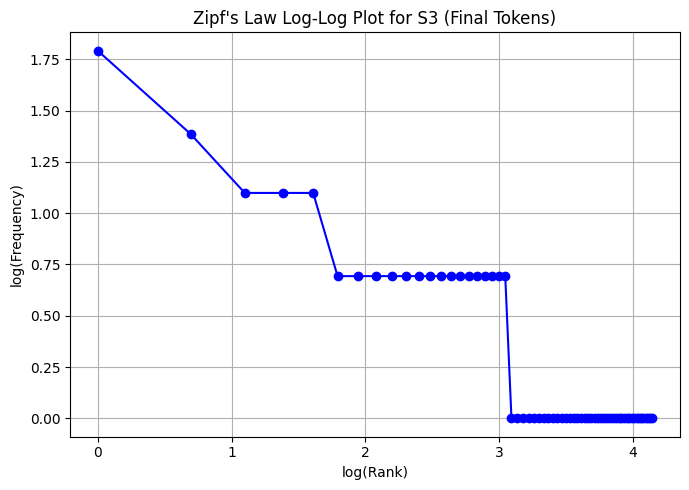

In [9]:
# Your code
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define Corpus Stages
S1 = [t for text in df["Ticket_Text"] for t in process_ticket(text)["tokens"]]
S2 = [
    t
    for text in df["Ticket_Text"]
    for t in process_ticket(text)["tokens"]
    if not is_punct(t)
]
S3 = [t for text in df["Ticket_Text"] for t in process_ticket(text)["final"]]
S4 = [porter.stem(t) for t in S3]

# Compute Stats
stats = []
for name, corpus in zip(["S1", "S2", "S3", "S4"], [S1, S2, S3, S4]):
    total = len(corpus)
    unique = len(set(corpus))
    ttr = unique / total if total > 0 else 0
    stats.append(
        {
            "Stage": name,
            "Total Tokens": total,
            "Unique Tokens": unique,
            "TTR (Type-Token Ratio)": round(ttr, 4),
        }
    )

stats_df = pd.DataFrame(stats)
print("=== Corpus Statistics Table ===")
print(stats_df.to_string(index=False))

# Top 10 words of S1 and S3
print("\n=== Top 10 Words ===")
print("S1 (All tokens):", Counter(S1).most_common(10))
print("S3 (Final tokens):", Counter(S3).most_common(10))

# Top 5 Bigrams of S1 and S3
s1_bigrams = list(zip(S1[:-1], S1[1:]))
s3_bigrams = list(zip(S3[:-1], S3[1:]))

print("\n=== Top 5 Bigrams ===")
print("S1 Bigrams:", Counter(s1_bigrams).most_common(5))
print("S3 Bigrams:", Counter(s3_bigrams).most_common(5))

# Plot log(rank) vs log(frequency) for S3
counts = Counter(S3)
freqs = sorted(counts.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(7, 5))
plt.plot(np.log(ranks), np.log(freqs), marker="o", linestyle="-", color="b")
plt.xlabel("log(Rank)")
plt.ylabel("log(Frequency)")
plt.title("Zipf's Law Log-Log Plot for S3 (Final Tokens)")
plt.grid(True)
plt.tight_layout()
plt.show()

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*

(a) Why does TTR change from S1 to S4 in your dataset?S1 $\rightarrow$ S2 (Increases: $0.4700 \rightarrow 0.5207$): Stripping punctuation removes heavily repeated single characters (like periods . and question marks ?), reducing total tokens much faster than unique types.   S2 $\rightarrow$ S3 (Increases: $0.5207 \rightarrow 0.5532$): Removing high-frequency functional stopwords (e.g., "the", "is", "i") eliminates high-repetition tokens, increasing the concentration of unique words.   S3 $\rightarrow$ S4 (Decreases: $0.5532 \rightarrow 0.4894$): Stemming collapses multiple inflected word forms (like "crashes" and "crash", or "restarting" and "restart") into a single root. Since total token count remains unchanged ($94$), reducing unique types from $52$ to $46$ lowers the ratio.   
(b) Example where word_tokenize() and my_tokenize() differExample Word: "isn't" or "can't"   Difference: word_tokenize() uses Penn Treebank conventions to split contractions into two separate tokens: ['is', "n't"] or ['ca', "n't"]. my_tokenize() preserves contractions intact as a single token: ["isn't"] or ["can't"].   
(c) Example where stemming produces an undesirable resultExample Word: "latest"   Undesirable Output: Lancaster Stemmer reduces "latest" to "lat".   Explanation: This is an example of over-stemming, where aggressive suffix stripping chops off valid root letters, distorting the word's original meaning and potentially grouping it with unrelated words like "latitude" or "lateral".   
(d) Example where POS-aware lemmatization preserves meaning better than stemmingExample Word: "tried"   Outputs: Porter Stemmer $\rightarrow$ "tri" | POS-aware WordNet Lemmatizer $\rightarrow$ "try".   Explanation: Porter Stemmer heuristically strips -ed and replaces -y with -i, generating the non-dictionary stem "tri". POS-aware lemmatization uses dictionary lookup with verb tagging (POS=v) to accurately map "tried" back to its valid dictionary base form "try", preserving semantic clarity.